# Modelo base — versión simplificada

**Qué busca este notebook.** Probar un primer modelo de aprendizaje automático que predice la
**cantidad de siniestros por día** en un municipio de Montevideo, y compararlo contra
**referencias simples** (línea base) bajo las mismas reglas.

**Pasos:**

1. Cargar la serie diaria que exporta el ETL.
2. Mirar la serie: forma general, patrón semanal y parecido con días anteriores.
3. Separar entrenamiento (80 %) y prueba (20 % final), respetando el orden en el tiempo.
4. Entrenar un árbol de decisión que predice a partir de los últimos 7 días.
5. Construir la línea base.
6. Comparar: primero en una semana, después en **todo** el conjunto de prueba.

> **Alcance.** Trabaja una sola serie: MUNICIPIO C, el municipio con más siniestros registrados.
> Sirve para fijar el procedimiento, **no** para afirmar que el modelo funciona en toda Montevideo.
> Es una versión más simple de `base.ipynb`: usa la misma partición y la misma línea base, así que
> las cifras de los dos notebooks se pueden comparar.

Tablas y figuras: `experiments/base_2/`. Resumen para el informe: `documentacion/resumen_base_2.md`.

## 0. Entorno

`skforecast` no está en `requirements.txt`, así que se instala desde el notebook, con la versión
usada en la corrida. **Ojo:** `skforecast` 0.25 exige pandas menor a 3, y `requirements.txt` fija
pandas 3.0.5; instalarlo baja pandas a la serie 2.x. Es una decisión pendiente del equipo
(`HANDOFF.md`). Las versiones efectivas de cada corrida quedan en `tablas/00_entorno.csv`.

In [1]:
# skforecast no está en requirements.txt: lo instalamos en el entorno del kernel.
%pip install skforecast==0.25.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Rutas, fechas y utilidades
from pathlib import Path
from datetime import datetime
import platform
from IPython.display import display

# Visualización
import matplotlib
import matplotlib.pyplot as plt

# Análisis de series temporales
import statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Modelo y métricas
import sklearn
import skforecast
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skforecast.recursive import ForecasterRecursive

# Semilla global: el árbol de decisión la usa como random_state.
SEMILLA = 42
np.random.seed(SEMILLA)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

versiones = {
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "statsmodels": statsmodels.__version__,
    "scikit-learn": sklearn.__version__,
    "skforecast": skforecast.__version__,
}
for nombre, version in versiones.items():
    print(f"{nombre:13s}", version)

python        3.13.2
pandas        2.3.3
numpy         2.5.2
matplotlib    3.11.1
statsmodels   0.14.6
scikit-learn  1.9.0
skforecast    0.25.0


In [3]:
# Ubicamos la raíz del repositorio: el notebook puede ejecutarse desde la raíz
# (VS Code) o desde la carpeta notebooks/ (jupyter nbconvert).
_cwd = Path.cwd()
RAIZ = _cwd if (_cwd / "data").exists() else _cwd.parent

RUTA_DATOS = RAIZ / "data" / "processed" / "panel_zona_top.csv"
DIR_TABLAS = RAIZ / "experiments" / "base_2" / "tablas"
DIR_FIGURAS = RAIZ / "experiments" / "base_2" / "figuras"
DIR_TABLAS.mkdir(parents=True, exist_ok=True)
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)


def guardar_tabla(tabla, nombre):
    """Guarda una tabla en experiments/base_2/tablas/."""
    ruta = DIR_TABLAS / nombre
    tabla.to_csv(ruta, index=False, encoding="utf-8")
    print("tabla guardada :", ruta.relative_to(RAIZ).as_posix())


def guardar_figura(fig, nombre):
    """Guarda una figura en experiments/base_2/figuras/."""
    ruta = DIR_FIGURAS / nombre
    fig.savefig(ruta, bbox_inches="tight")
    print("figura guardada:", ruta.relative_to(RAIZ).as_posix())


entorno = pd.DataFrame({"componente": list(versiones), "version": list(versiones.values())})
entorno.loc[len(entorno)] = ["fecha_ejecucion", datetime.now().strftime("%Y-%m-%d %H:%M")]
guardar_tabla(entorno, "00_entorno.csv")

tabla guardada : experiments/base_2/tablas/00_entorno.csv


## 1. Carga de datos

`data/processed/panel_zona_top.csv` lo genera el ETL (`notebooks/preparacion_montevideo.ipynb`):
una fila por día para el municipio con más siniestros. La variable a predecir es `n_siniestros`,
la cantidad de siniestros registrados ese día.

> Este archivo **no debe abrirse y guardarse desde Excel**: Excel lo reescribe con `;` y fechas
> `dd/mm/aaaa`, y el notebook deja de leerlo.

In [4]:
# La fecha es el índice. Se lee con formato explícito: si pandas lo adivina,
# una fecha escrita como 01/07/2021 puede leerse como 7 de enero sin avisar.
df = pd.read_csv(RUTA_DATOS, index_col="fecha")
df.index = pd.to_datetime(df.index, format="%Y-%m-%d")

MUNICIPIO = df["zona_id"].iloc[0]
print("Municipio:", MUNICIPIO)
df.head()

Municipio: MUNICIPIO C


,zona_id,n_siniestros,tipo_dia,temp_media,temp_max,temp_min,precipitacion_mm,lluvia_mm,viento_max_kmh,estado_clima,llovio
fecha,,,,,,,,,,,
2021-07-01,MUNICIPIO C,5,entre_semana,11.2,14.9,9.4,0.0,0.0,19.6,nublado,0
2021-07-02,MUNICIPIO C,8,entre_semana,10.4,13.0,8.5,0.0,0.0,22.7,nublado,0
2021-07-03,MUNICIPIO C,2,fin_semana,10.9,14.7,8.0,0.0,0.0,24.4,despejado,0
2021-07-04,MUNICIPIO C,4,fin_semana,9.8,15.0,6.0,0.0,0.0,20.4,nublado,0
2021-07-05,MUNICIPIO C,2,entre_semana,9.7,15.7,5.2,0.0,0.0,14.8,despejado,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1645 entries, 2021-07-01 to 2025-12-31
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   zona_id           1645 non-null   object 
 1   n_siniestros      1645 non-null   int64  
 2   tipo_dia          1645 non-null   object 
 3   temp_media        1645 non-null   float64
 4   temp_max          1645 non-null   float64
 5   temp_min          1645 non-null   float64
 6   precipitacion_mm  1645 non-null   float64
 7   lluvia_mm         1645 non-null   float64
 8   viento_max_kmh    1645 non-null   float64
 9   estado_clima      1645 non-null   object 
 10  llovio            1645 non-null   int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 154.2+ KB


In [6]:
# Revisamos desde cuándo hasta cuándo llega la serie temporal.
# Como "fecha" es el índice, usamos df.index.min() y df.index.max().
df.index.min(), df.index.max()

(Timestamp('2021-07-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [7]:
# Calculamos la diferencia de tiempo entre cada observación y la anterior.
# Luego contamos cuántas veces aparece cada separación temporal.
df.index.to_series().diff().value_counts().head()

fecha
1 days    1644
Name: count, dtype: int64

**Lectura.** La serie tiene 1.645 días, del 2021-07-01 al 2025-12-31, y cada fecha está exactamente a
1 día de la anterior (1.644 diferencias de 1 día): **no faltan días**. Ninguna columna tiene valores
nulos. Además de `n_siniestros`, el archivo trae `tipo_dia` (lo usa la línea base) y variables de
clima, que este notebook **no usa**: el diagnóstico de datos mostró que, fuera de muestra, el clima
no mejora las predicciones.

## 2. La serie completa

Primera vista de los datos: un valor por día, en todo el período.

figura guardada: experiments/base_2/figuras/fig1_serie.png


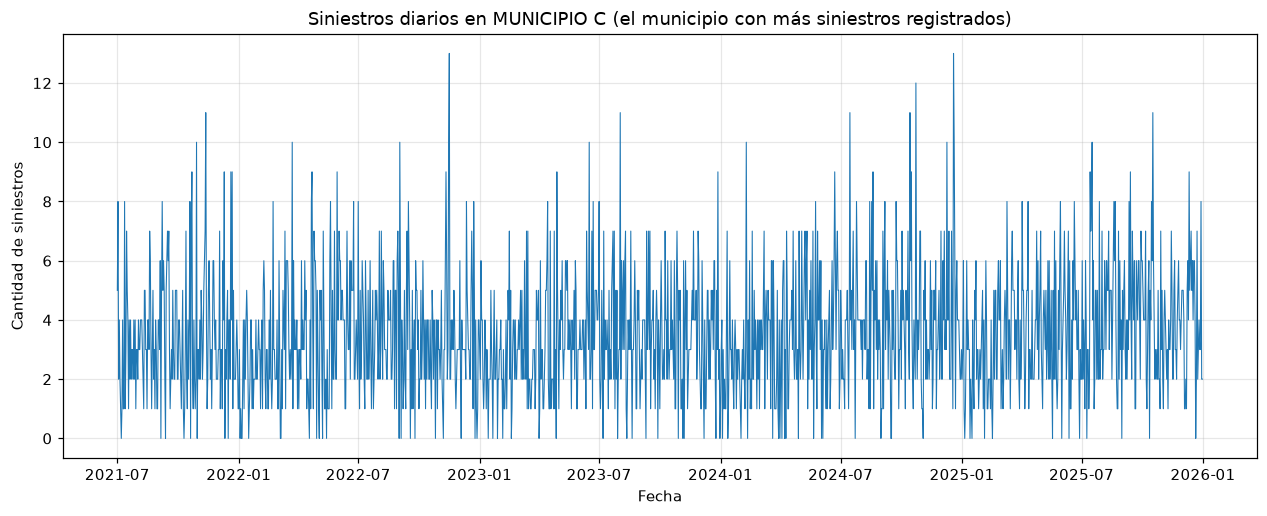

Mínimo: 0 | Máximo: 13 | Promedio: 3.52


In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["n_siniestros"], linewidth=0.7)

ax.set_title(f"Siniestros diarios en {MUNICIPIO} (el municipio con más siniestros registrados)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de siniestros")
guardar_figura(fig, "fig1_serie.png")
plt.show()

print("Mínimo:", df["n_siniestros"].min(),
      "| Máximo:", df["n_siniestros"].max(),
      "| Promedio:", round(df["n_siniestros"].mean(), 2))

**Lectura.** Los siniestros por día van de 0 a 13, con un promedio de 3,52. La serie es muy ruidosa:
de un día a otro puede pasar de 1 a 8 sin motivo visible, y a simple vista no se distingue ningún
patrón. Para encontrarlos hay que mirarla por partes (secciones 4 y 5).

## 3. Entrenamiento y prueba

En una serie temporal los días no se mezclan al azar: el modelo aprende con el **pasado** y se
evalúa sobre el **futuro**, como pasaría si se usara de verdad. Se reserva el **20 % final** como
conjunto de prueba.

**Regla desde acá:** todo análisis, promedio o ajuste se calcula **solo con entrenamiento**. La
prueba se usa únicamente para evaluar, en las secciones 8 y 9.

In [9]:
# Definimos el tamaño del conjunto de prueba: el 20% final de la serie.
n_test = int(len(df) * 0.2)

# Partición temporal: el pasado entrena, el futuro evalúa.
train = df.iloc[:-n_test].copy()
test = df.iloc[-n_test:].copy()

particion = pd.DataFrame({
    "conjunto": ["entrenamiento", "prueba"],
    "desde": [train.index.min().date(), test.index.min().date()],
    "hasta": [train.index.max().date(), test.index.max().date()],
    "dias": [len(train), len(test)],
    "porcentaje": [round(100 * len(train) / len(df), 1), round(100 * len(test) / len(df), 1)],
    # Descriptivo: no se usa para ajustar nada.
    "promedio_siniestros_por_dia": [round(train["n_siniestros"].mean(), 3), round(test["n_siniestros"].mean(), 3)],
})
guardar_tabla(particion, "01_particion.csv")
particion

tabla guardada : experiments/base_2/tablas/01_particion.csv


,conjunto,desde,hasta,dias,porcentaje,promedio_siniestros_por_dia
0,entrenamiento,2021-07-01,2025-02-05,1316,80.0,3.426
1,prueba,2025-02-06,2025-12-31,329,20.0,3.875


figura guardada: experiments/base_2/figuras/fig2_particion.png


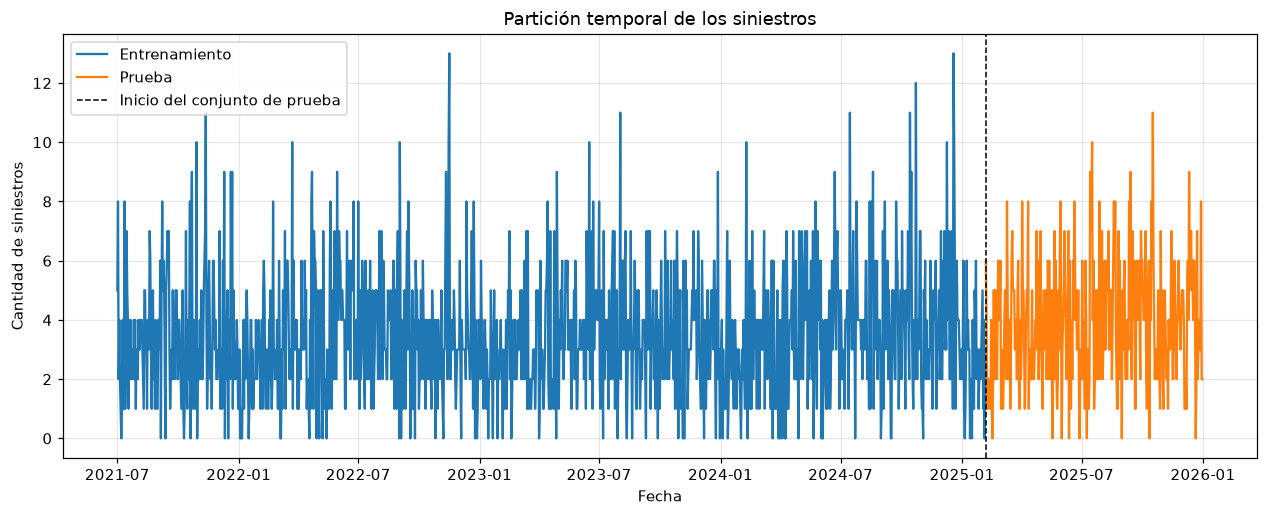

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index, train["n_siniestros"], color="tab:blue", label="Entrenamiento")
ax.plot(test.index, test["n_siniestros"], color="tab:orange", label="Prueba")
ax.axvline(test.index.min(), color="black", linestyle="--", linewidth=1,
           label="Inicio del conjunto de prueba")

ax.set_title("Partición temporal de los siniestros")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de siniestros")
ax.legend()
guardar_figura(fig, "fig2_particion.png")
plt.show()

**Lectura** (tabla `01_particion`). Entrenamiento: 1.316 días (2021-07-01 → 2025-02-05). Prueba: 329
días (2025-02-06 → 2025-12-31).

**Dato importante para después:** la prueba promedia **3,875** siniestros por día y el entrenamiento
**3,426**, un 13 % más. Los siniestros registrados crecieron con el tiempo (el diagnóstico de datos ya
lo había detectado), así que un modelo que aprende un nivel fijo del pasado va a tender a **predecir
de menos** en la prueba. El promedio de prueba se muestra solo como descripción: no se usa para
ajustar nada.

## 4. Patrón semanal: descomposición

La descomposición separa la serie de entrenamiento en tres partes que, sumadas, la reconstruyen:

- **Tendencia (Trend):** el nivel general, suavizado con un promedio móvil de 7 días.
- **Estacionalidad (Seasonal):** un patrón que se repite igual cada 7 días.
- **Residuo (Resid):** lo que queda sin explicar, el ruido del día a día.

figura guardada: experiments/base_2/figuras/fig3_descomposicion.png


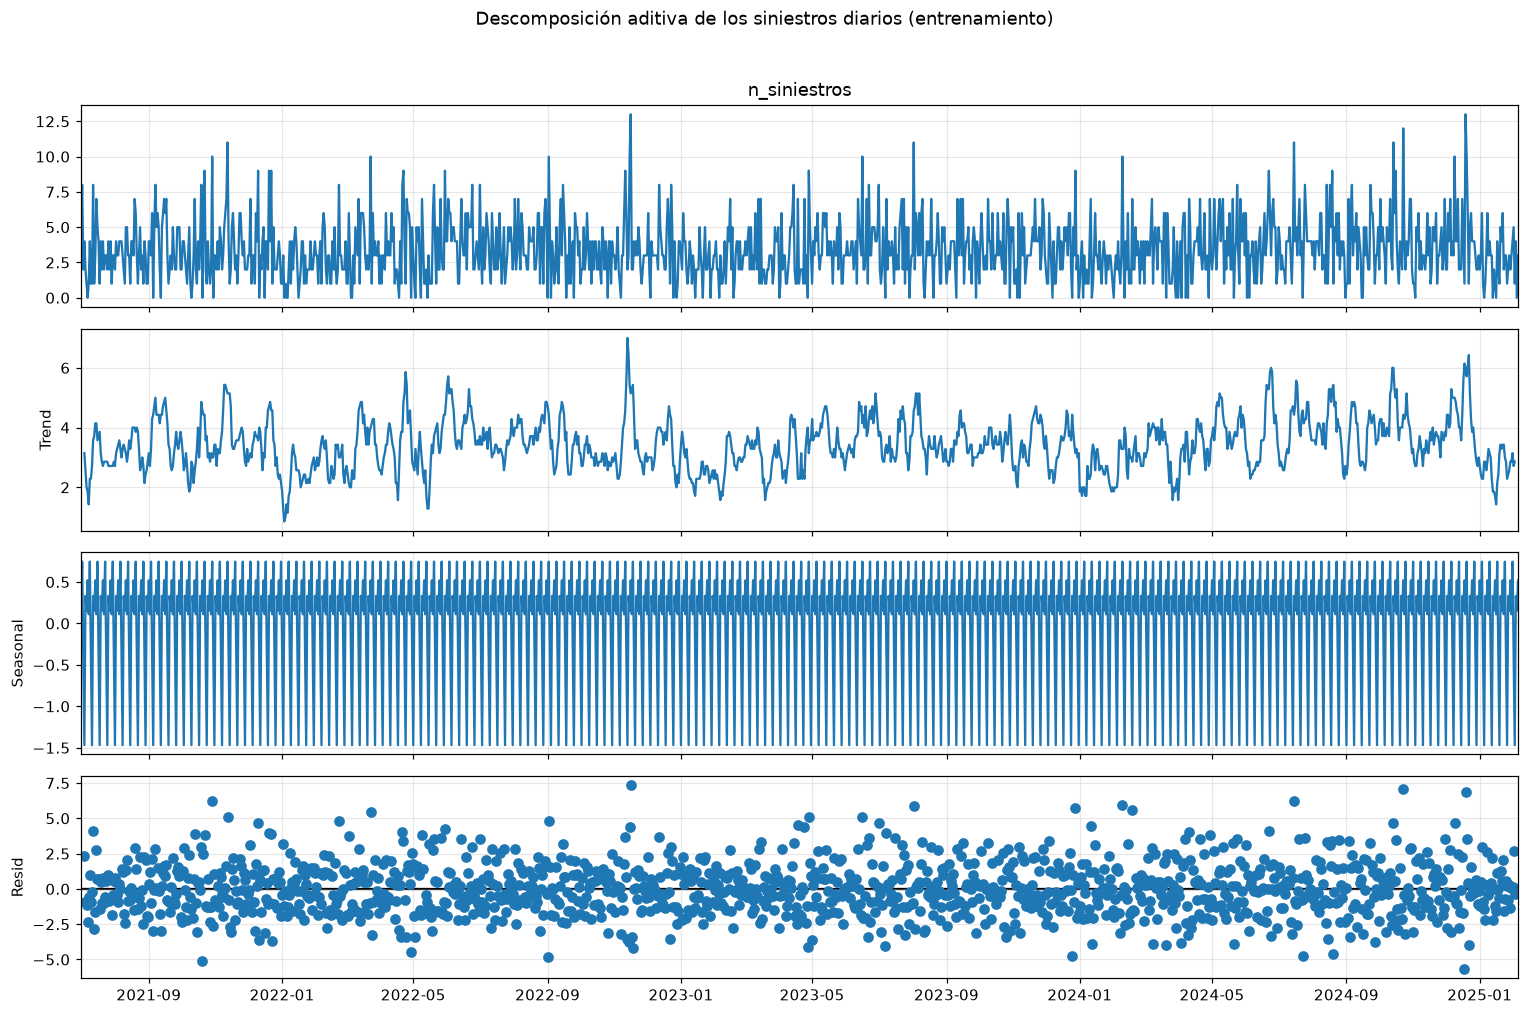

tabla guardada : experiments/base_2/tablas/02b_descomposicion_resumen.csv


,parte,porcentaje_de_la_variacion,minimo,maximo
0,tendencia,16.5,0.86,7.00
1,estacionalidad semanal,10.6,-1.47,0.75
2,residuo,73.7,-5.66,7.34


In [11]:
# Serie objetivo de entrenamiento: la usamos en todo el análisis exploratorio.
serie_train = train["n_siniestros"]

# Descomposición aditiva con un patrón de 7 días (semanal).
descomposicion = seasonal_decompose(serie_train, model="additive", period=7)

fig = descomposicion.plot()
fig.set_size_inches(14, 9)
fig.suptitle("Descomposición aditiva de los siniestros diarios (entrenamiento)", y=1.02)
plt.tight_layout()
guardar_figura(fig, "fig3_descomposicion.png")
plt.show()

# ¿Cuánto de la variación de la serie corresponde a cada parte?
# Los porcentajes no suman exactamente 100 % porque las partes no son del todo independientes.
varianza_serie = serie_train.var()
partes = {"tendencia": descomposicion.trend, "estacionalidad semanal": descomposicion.seasonal,
          "residuo": descomposicion.resid}
resumen_descomposicion = pd.DataFrame({
    "parte": list(partes),
    "porcentaje_de_la_variacion": [round(100 * p.var() / varianza_serie, 1) for p in partes.values()],
    "minimo": [round(p.min(), 2) for p in partes.values()],
    "maximo": [round(p.max(), 2) for p in partes.values()],
})
guardar_tabla(resumen_descomposicion, "02b_descomposicion_resumen.csv")
resumen_descomposicion

tabla guardada : experiments/base_2/tablas/02_patron_semanal.csv


,dia_semana,efecto_estacional,promedio_siniestros
0,lunes,0.332,3.761
1,martes,0.153,3.559
2,miércoles,0.520,3.941
3,jueves,0.111,3.543
4,viernes,0.745,4.191
5,sábado,-0.393,3.027
6,domingo,-1.468,1.957


figura guardada: experiments/base_2/figuras/fig4_patron_semanal.png


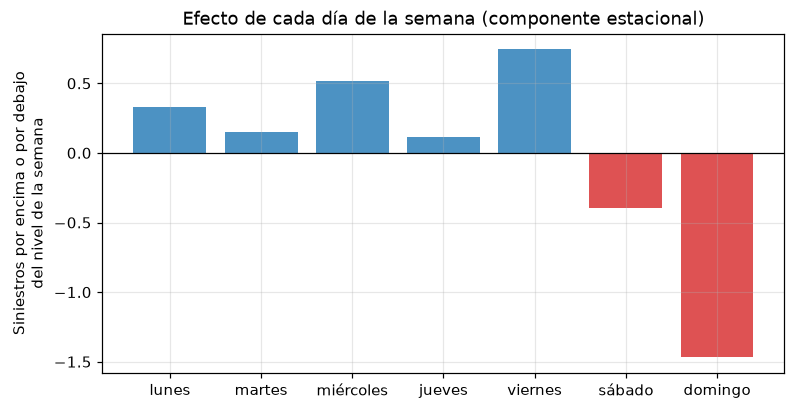

In [12]:
# El panel «Seasonal» repite el mismo patrón de 7 días más de 180 veces, y así no se lee.
# Como el patrón es igual todas las semanas, alcanza con mirar una semana.
DIAS = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
estacional = descomposicion.seasonal

patron_semanal = pd.DataFrame({
    "dia_semana": DIAS,
    "efecto_estacional": estacional.groupby(estacional.index.dayofweek).mean().round(3).values,
    "promedio_siniestros": serie_train.groupby(serie_train.index.dayofweek).mean().round(3).values,
})
guardar_tabla(patron_semanal, "02_patron_semanal.csv")
display(patron_semanal)

fig, ax = plt.subplots(figsize=(8, 4))
colores = ["tab:red" if v < 0 else "tab:blue" for v in patron_semanal["efecto_estacional"]]
ax.bar(patron_semanal["dia_semana"], patron_semanal["efecto_estacional"], color=colores, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Efecto de cada día de la semana (componente estacional)")
ax.set_ylabel("Siniestros por encima o por debajo\ndel nivel de la semana")
guardar_figura(fig, "fig4_patron_semanal.png")
plt.show()

**Lectura** (tablas `02b_descomposicion_resumen` y `02_patron_semanal`).

- **El ruido domina.** El residuo concentra el **73,7 %** de la variación de la serie; la tendencia, el
  16,5 %, y el patrón semanal, el 10,6 %. La mayor parte de lo que pasa día a día no la explican ni el
  nivel general ni el día de la semana.
- **La «tendencia» de este gráfico no es la de largo plazo.** Es un promedio de 7 días, así que sube y
  baja con cada semana buena o mala (entre 0,86 y 7,00). El crecimiento entre años se ve mejor en los
  promedios de la sección 3.
- **Sí hay un patrón semanal claro.** El domingo tiene **1,47 siniestros menos** que el nivel de su
  semana y el sábado 0,39 menos. De lunes a viernes todos los días quedan por encima, y el viernes es
  el más alto (+0,75). En promedios: **1,96 siniestros los domingos contra 4,19 los viernes**.

Consecuencia: el **tipo de día** es información útil para predecir, y es justo lo que usa la línea
base de la sección 7.

## 5. ¿Se parece un día a los anteriores? Autocorrelación

La **autocorrelación** a *k* días mide cuánto se parece la cantidad de siniestros de un día a la de
*k* días antes: 0 es ninguna relación y 1 es idénticos. En el gráfico, la **franja celeste** es el
margen que puede aparecer por azar: una barra dentro de la franja no se distingue de cero.

Importa para el modelo: el árbol de la sección 6 predice **solo** a partir de los 7 días anteriores.
Si esos días se parecen poco al día a predecir, el árbol tiene poca información con la que trabajar.

,n_siniestros,dia_anterior,semana_anterior
fecha,,,
2021-07-01,5,NaN,NaN
2021-07-02,8,5.0,NaN
2021-07-03,2,8.0,NaN
2021-07-04,4,2.0,NaN
2021-07-05,2,4.0,NaN
2021-07-06,1,2.0,NaN
2021-07-07,0,1.0,NaN
2021-07-08,1,0.0,5.0
2021-07-09,4,1.0,8.0


tabla guardada : experiments/base_2/tablas/03_autocorrelacion.csv


,rezago_dias,autocorrelacion,margen_azar_aprox,fuera_del_margen
0,1,0.056,0.054,True
1,7,0.077,0.054,True
2,14,0.165,0.054,True
3,21,0.098,0.054,True
4,28,0.112,0.054,True


figura guardada: experiments/base_2/figuras/fig5_acf.png


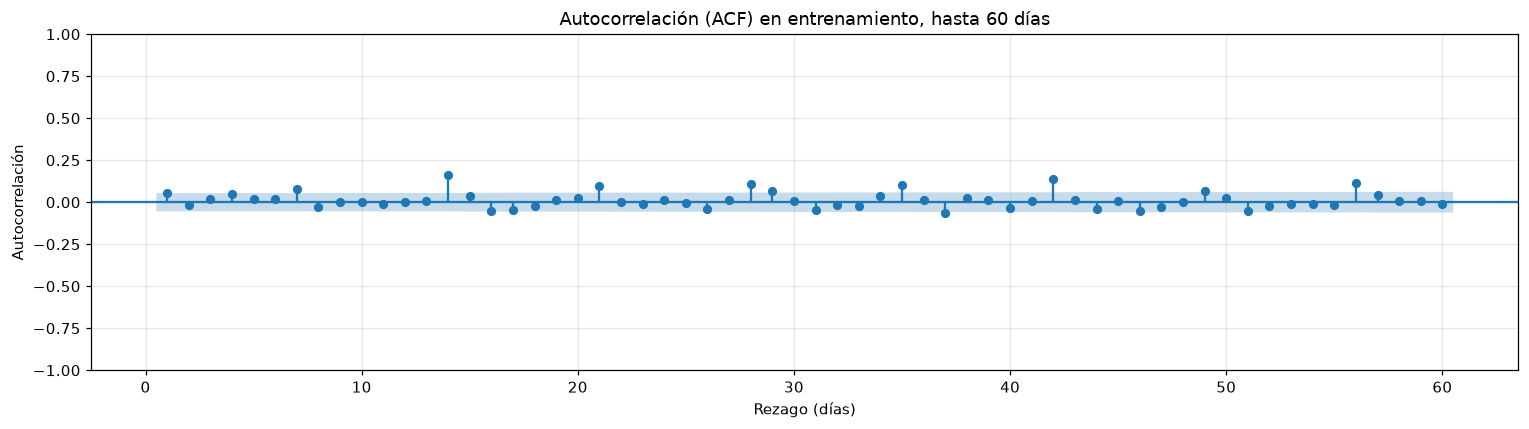

In [13]:
# Tabla auxiliar: cada día junto al día anterior y a la semana anterior.
comparacion = pd.DataFrame({
    "n_siniestros": serie_train,
    "dia_anterior": serie_train.shift(1),
    "semana_anterior": serie_train.shift(7),
})
display(comparacion.head(10))

# Autocorrelación en algunos rezagos, solo con entrenamiento.
# El margen por azar es aproximado (1,96 / raíz de n); el gráfico usa una versión más precisa.
rezagos = [1, 7, 14, 21, 28]
margen_azar = 1.96 / np.sqrt(len(serie_train))
autocorrelacion = pd.DataFrame({
    "rezago_dias": rezagos,
    "autocorrelacion": [round(serie_train.autocorr(k), 3) for k in rezagos],
})
autocorrelacion["margen_azar_aprox"] = round(margen_azar, 3)
autocorrelacion["fuera_del_margen"] = autocorrelacion["autocorrelacion"].abs() > margen_azar
guardar_tabla(autocorrelacion, "03_autocorrelacion.csv")
display(autocorrelacion)

# Gráfico de autocorrelación hasta 60 días (unos dos meses).
n_rezagos = 60
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(serie_train, lags=n_rezagos, zero=False, ax=ax)
ax.set_title(f"Autocorrelación (ACF) en entrenamiento, hasta {n_rezagos} días")
ax.set_xlabel("Rezago (días)")
ax.set_ylabel("Autocorrelación")
plt.tight_layout()
guardar_figura(fig, "fig5_acf.png")
plt.show()

**Lectura** (tabla `03_autocorrelacion`, figura `fig5_acf`).

- Las barras que salen de la franja están casi todas en **múltiplos de 7 días** (7, 14, 21, 28… hasta
  56). Es el patrón semanal de la sección 4: un viernes se parece a otros viernes, y un domingo a otros
  domingos.
- El parecido con el **día anterior** apenas se nota: 0,056, en el borde del margen por azar (0,054).
- **Todas las relaciones son débiles.** La más alta, a 14 días, es 0,165. Conocer los días anteriores
  ayuda poco a anticipar el siguiente.

Consecuencia para el árbol: los 7 días anteriores traen poca información, y la que traen es sobre todo
el patrón semanal, que el tipo de día da de forma más directa.

La **autocorrelación parcial** (PACF) mide lo mismo, pero descontando lo que ya explican los días
intermedios. Sirve para ver si el parecido con la semana anterior es directo o se arrastra día a día.

figura guardada: experiments/base_2/figuras/fig6_pacf.png


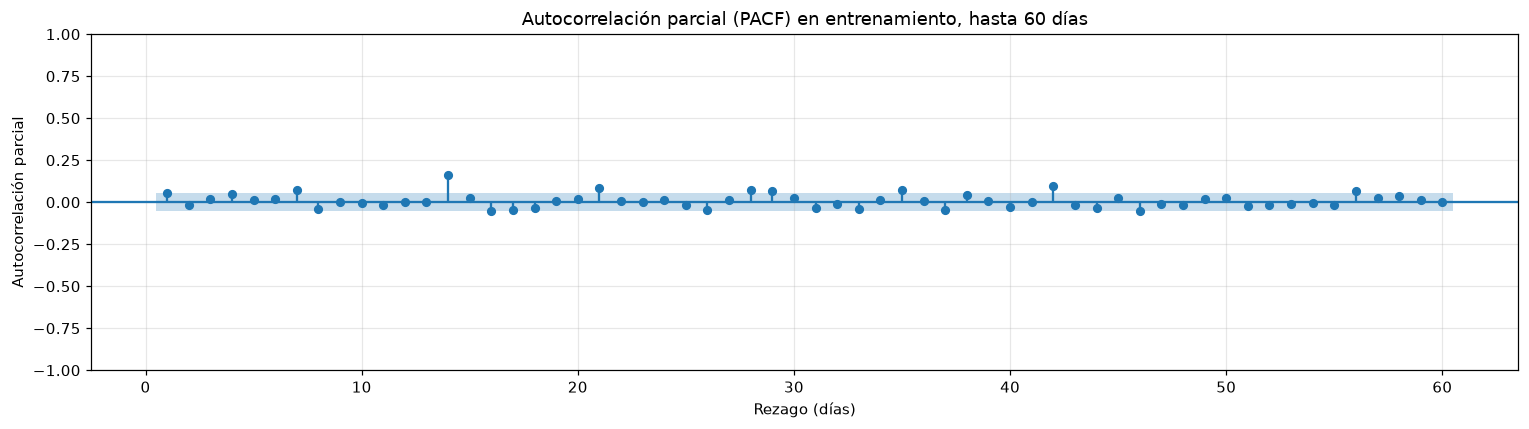

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_pacf(serie_train, lags=n_rezagos, method="ywm", zero=False, ax=ax)
ax.set_title(f"Autocorrelación parcial (PACF) en entrenamiento, hasta {n_rezagos} días")
ax.set_xlabel("Rezago (días)")
ax.set_ylabel("Autocorrelación parcial")
plt.tight_layout()
guardar_figura(fig, "fig6_pacf.png")
plt.show()

**Lectura** (figura `fig6_pacf`). Después de descontar los días intermedios, siguen sobresaliendo los
rezagos múltiplos de 7, con valores algo menores. El parecido semanal es **directo**, no se arrastra
día a día: lo que aparece en la autocorrelación es el patrón del día de la semana, no una «memoria» de
corto plazo.

## 6. Modelo: árbol de decisión con `skforecast`

`ForecasterRecursive` convierte la serie en una tabla: para cada día, las variables son los
siniestros de los **7 días anteriores** (`lags=7`) y el objetivo es el siniestro de ese día. Sobre
esa tabla se entrena un **árbol de decisión**, que aprende reglas del tipo «si hace 7 días hubo
más de 5 siniestros y ayer menos de 2, predecir 4».

Para predecir más de un día hacia adelante, el modelo usa su propia predicción como si fuera un
dato observado: predice el día 1, lo agrega a la historia, predice el día 2, y así (**predicción
recursiva**).

`max_depth=15` se fijó a mano. Elegir la profundidad con datos de validación es trabajo del
Entregable 3; acá se registra el tamaño del árbol, que indica si **aprende patrones** o **memoriza
días**.

In [15]:
forecaster = ForecasterRecursive(
    estimator=DecisionTreeRegressor(
        max_depth=15,
        random_state=SEMILLA
    ),
    lags=7
)

# skforecast necesita que el índice tenga una frecuencia explícita.
frecuencia = pd.infer_freq(train.index)
if frecuencia is None:
    raise ValueError("No se pudo inferir la frecuencia temporal del índice de train.")

y_train = train["n_siniestros"].asfreq(frecuencia)
y_test = test["n_siniestros"].asfreq(frecuencia)

# Verificamos que fijar la frecuencia no haya creado días faltantes.
if y_train.isna().any() or y_test.isna().any():
    raise ValueError("El índice contiene fechas faltantes después de establecer la frecuencia.")

forecaster.fit(y=y_train)
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: DecisionTreeRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Calendar features: None 
Window size: 7 
Series name: n_siniestros 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2021-07-01 00:00:00'), Timestamp('2025-02-05 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 15,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2026-09-14 13:37:01 
Last fit date: 2026-09-14 13:37:01 
Skforecast version: 0.25.0 
Python version: 3.13.2 
Forecaster id: None

In [16]:
# ¿Aprende patrones o memoriza días? Comparamos la cantidad de hojas con las filas de entrenamiento.
# Los primeros 7 días no tienen 7 días previos, así que no entran a la tabla de entrenamiento.
arbol = forecaster.estimator
filas_ajuste = len(y_train) - forecaster.window_size

tamano_arbol = pd.DataFrame({
    "indicador": ["filas de entrenamiento", "profundidad", "hojas", "filas por hoja (promedio)"],
    "valor": pd.Series([filas_ajuste, arbol.get_depth(), arbol.get_n_leaves(),
                        round(filas_ajuste / arbol.get_n_leaves(), 2)], dtype="object"),
})
guardar_tabla(tamano_arbol, "04_tamano_arbol.csv")
tamano_arbol

tabla guardada :

 experiments/base_2/tablas/04_tamano_arbol.csv


,indicador,valor
0,filas de entrenamiento,1309
1,profundidad,15
2,hojas,527
3,filas por hoja (promedio),2.48


**Lectura** (tabla `04_tamano_arbol`). El árbol tiene **527 hojas para 1.309 filas** de entrenamiento:
en promedio, **2,48 días por hoja**. Cada hoja es casi un día concreto del pasado, así que el árbol
**memoriza** días en lugar de aprender reglas generales. Es esperable que acierte con los datos que vio
y falle con los nuevos; la sección 9 lo comprueba.

## 7. Línea base

Un modelo solo es útil si mejora algo más simple. Se construyen tres referencias, **todas
calculadas solo con entrenamiento**:

| Referencia | Qué predice |
| --- | --- |
| **Media constante** | El promedio de entrenamiento, todos los días. Es el piso. |
| **Promedio por tipo de día** ← *línea base* | El promedio de entrenamiento de ese tipo de día: entre semana, fin de semana o feriado. |
| **Repetir semana anterior** | Lo que pasó 7 días antes. La referencia más habitual en series temporales. |

El **promedio por tipo de día** es la línea base del proyecto. Es la misma que `base.ipynb` llama
«tasa × calendario», y la que el diagnóstico de datos midió como la mejor forma simple disponible.

tabla guardada : experiments/base_2/tablas/05_linea_base.csv


,tipo_dia,dias_entrenamiento,promedio_siniestros
0,entre_semana,891,3.879
1,fin_semana,364,2.505
2,feriado,61,2.295
3,todos (media constante),1316,3.426


figura guardada: experiments/base_2/figuras/fig7_linea_base.png


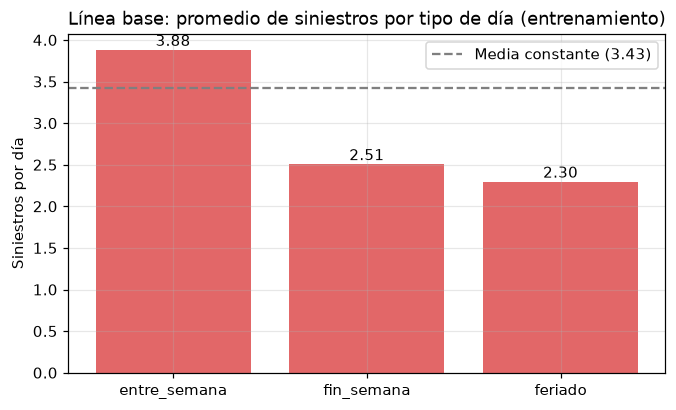

In [17]:
ARBOL = "Árbol de decisión"
LINEA_BASE = "Promedio por tipo de día (línea base)"
MODELOS = [ARBOL, "Media constante", LINEA_BASE, "Repetir semana anterior"]

# Todo se calcula solo con entrenamiento.
media_train = y_train.mean()
media_por_tipo = train.groupby("tipo_dia")["n_siniestros"].mean()

orden_tipos = ["entre_semana", "fin_semana", "feriado"]
linea_base = pd.DataFrame({
    "tipo_dia": orden_tipos,
    "dias_entrenamiento": train["tipo_dia"].value_counts().reindex(orden_tipos).values,
    "promedio_siniestros": media_por_tipo.reindex(orden_tipos).round(3).values,
})
linea_base.loc[len(linea_base)] = ["todos (media constante)", len(train), round(media_train, 3)]
guardar_tabla(linea_base, "05_linea_base.csv")
display(linea_base)

# Serie completa con frecuencia diaria: «Repetir semana anterior» y el árbol
# necesitan los días ya observados antes de cada fecha a predecir.
serie_completa = df["n_siniestros"].asfreq(frecuencia)


def predecir_referencias(fechas):
    """Predicciones de las tres referencias simples para las fechas indicadas."""
    return {
        "Media constante": pd.Series(media_train, index=fechas),
        LINEA_BASE: df.loc[fechas, "tipo_dia"].map(media_por_tipo),
        "Repetir semana anterior": serie_completa.shift(7).loc[fechas],
    }


fig, ax = plt.subplots(figsize=(7, 4))
valores = media_por_tipo.reindex(orden_tipos)
ax.bar(orden_tipos, valores, color="tab:red", alpha=0.7)
ax.axhline(media_train, color="tab:gray", linestyle="--", label=f"Media constante ({media_train:.2f})")
for i, valor in enumerate(valores):
    ax.text(i, valor + 0.05, f"{valor:.2f}", ha="center")
ax.set_title("Línea base: promedio de siniestros por tipo de día (entrenamiento)")
ax.set_ylabel("Siniestros por día")
ax.legend()
guardar_figura(fig, "fig7_linea_base.png")
plt.show()

**Lectura** (tabla `05_linea_base`, figura `fig7_linea_base`). En entrenamiento, un día entre semana
promedia **3,88** siniestros, un fin de semana **2,51** y un feriado **2,30**. La media constante (3,43)
queda en el medio: se pasa en fines de semana y feriados, y se queda corta en los días hábiles. La
línea base corrige eso con solo tres números. Los feriados son pocos (61 días de entrenamiento), así
que su promedio es el menos preciso de los tres.

## 8. Primera mirada: la primera semana de prueba

Cada modelo predice los primeros 7 días del conjunto de prueba. Para compararlos se usan tres
métricas, calculadas sobre las predicciones sin redondear:

| Métrica | Cómo se lee |
| --- | --- |
| **MAE** | Siniestros de diferencia por día, en promedio. Menor es mejor. |
| **RMSE** | Parecido al MAE, pero castiga más los errores grandes. Menor es mejor. |
| **Total predicho / observado** | 1 = acierta el volumen total. Menor que 1 = predice menos siniestros de los que ocurrieron. |

In [18]:
def calcular_metricas(real, prediccion):
    """MAE, RMSE y total predicho sobre total observado."""
    return {
        "MAE": mean_absolute_error(real, prediccion),
        "RMSE": np.sqrt(mean_squared_error(real, prediccion)),
        "total_predicho_sobre_observado": prediccion.sum() / real.sum(),
    }


# Horizonte de predicción: los primeros 7 días del conjunto de prueba.
steps = 7
fechas_semana = y_test.index[:steps]

# El árbol predice de forma recursiva a partir de los últimos 7 días de entrenamiento.
pred_arbol = forecaster.predict(steps=steps)
assert pred_arbol.index.equals(fechas_semana), "las fechas predichas no son las de la prueba"

predicciones_semana = pd.DataFrame({
    "tipo_dia": df.loc[fechas_semana, "tipo_dia"],
    "valor_real": y_test.loc[fechas_semana],
    ARBOL: pred_arbol,
})
for nombre, prediccion in predecir_referencias(fechas_semana).items():
    predicciones_semana[nombre] = prediccion

guardar_tabla(predicciones_semana.round(3).rename_axis("fecha").reset_index(),
              "06_primera_semana_predicciones.csv")
predicciones_semana.round(2)

tabla guardada : experiments/base_2/tablas/06_primera_semana_predicciones.csv


,tipo_dia,valor_real,Árbol de decisión,Media constante,Promedio por tipo de día (línea base),Repetir semana anterior
2025-02-06,entre_semana,6,3.00,3.43,3.88,3.0
2025-02-07,entre_semana,4,3.47,3.43,3.88,4.0
2025-02-08,fin_semana,1,8.00,3.43,2.51,5.0
2025-02-09,fin_semana,1,3.00,3.43,2.51,1.0
2025-02-10,entre_semana,2,6.00,3.43,3.88,4.0
2025-02-11,entre_semana,2,1.00,3.43,3.88,0.0
2025-02-12,entre_semana,2,3.00,3.43,3.88,3.0


figura guardada: experiments/base_2/figuras/fig8_primera_semana.png


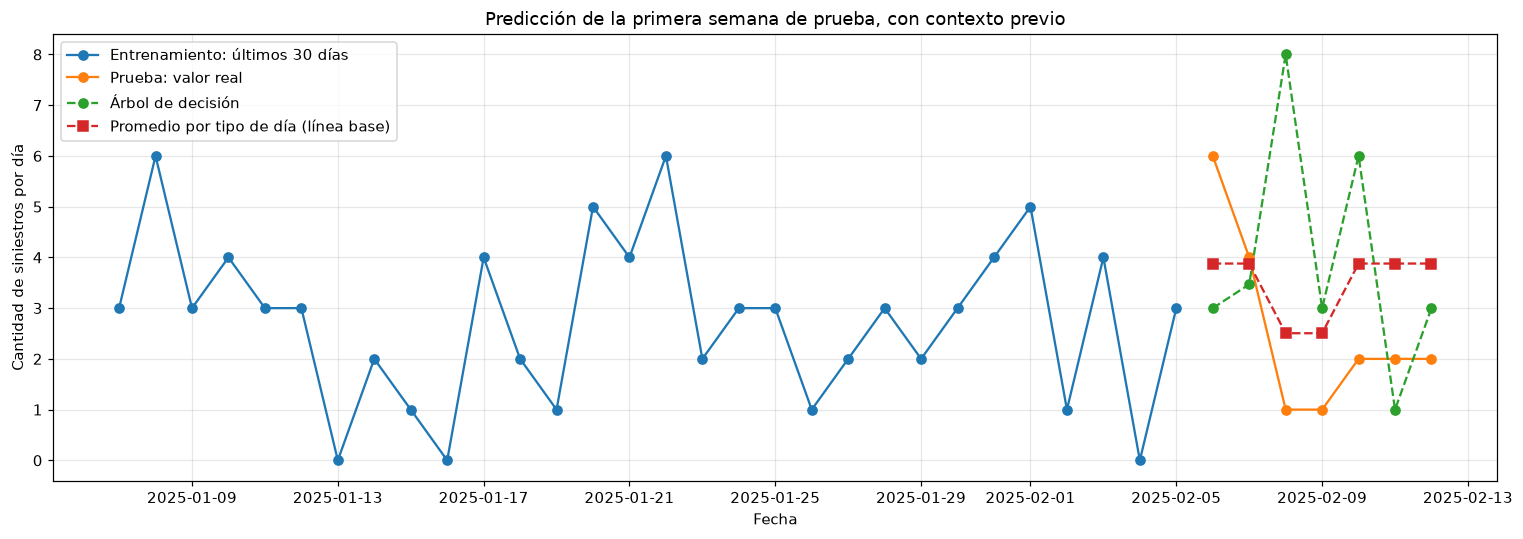

In [19]:
# Contexto: los últimos 30 días de entrenamiento antes de la semana predicha.
dias_contexto = 30
contexto = y_train.iloc[-dias_contexto:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(contexto.index, contexto, marker="o", color="tab:blue", label="Entrenamiento: últimos 30 días")
ax.plot(fechas_semana, predicciones_semana["valor_real"], marker="o", color="tab:orange",
        label="Prueba: valor real")
ax.plot(fechas_semana, predicciones_semana[ARBOL], marker="o", linestyle="--", color="tab:green",
        label=ARBOL)
ax.plot(fechas_semana, predicciones_semana[LINEA_BASE], marker="s", linestyle="--", color="tab:red",
        label=LINEA_BASE)

ax.set_title("Predicción de la primera semana de prueba, con contexto previo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de siniestros por día")
ax.legend()
plt.tight_layout()
guardar_figura(fig, "fig8_primera_semana.png")
plt.show()

In [20]:
metricas_semana = pd.DataFrame([
    {"modelo": m, **calcular_metricas(predicciones_semana["valor_real"], predicciones_semana[m])}
    for m in MODELOS
]).sort_values("MAE").round(3)

guardar_tabla(metricas_semana, "07_primera_semana_metricas.csv")
metricas_semana

tabla guardada : experiments/base_2/tablas/07_primera_semana_metricas.csv


,modelo,MAE,RMSE,total_predicho_sobre_observado
2,Promedio por tipo de día (línea base),1.556,1.675,1.356
3,Repetir semana anterior,1.714,2.204,1.111
1,Media constante,1.754,1.883,1.332
0,Árbol de decisión,2.647,3.387,1.526


**Lectura** (tablas `06_primera_semana_predicciones` y `07_primera_semana_metricas`, figura
`fig8_primera_semana`).

- **El árbol es el peor esta semana:** MAE 2,65, contra 1,56 de la línea base, 1,71 de repetir la
  semana anterior y 1,75 de la media constante.
- Sus errores grandes son saltos que no ocurrieron: predijo **8 siniestros el sábado 8 de febrero**
  (hubo 1) y 6 el lunes 10 (hubo 2).
- **Los cuatro modelos predicen de más** (total predicho / observado entre 1,11 y 1,53): esa semana tuvo
  solo 18 siniestros, pocos frente al promedio de prueba de 3,875 por día.

**Cuidado:** son 7 días, y una semana puede ser atípica, como esta. La sección siguiente repite la
comparación con todas las semanas.

## 9. Evaluación en todo el conjunto de prueba

Una semana no alcanza: con 7 días, el resultado depende mucho de qué semana tocó. Se repite la
evaluación sobre **todas las semanas** del conjunto de prueba:

1. Se parte del primer día de prueba.
2. Cada modelo predice los 7 días siguientes, usando solo lo observado hasta ese momento.
3. Se avanza una semana y se repite, hasta cubrir la prueba completa.

Los modelos **no se reentrenan**: quedan fijos con lo aprendido en entrenamiento, como si se hubieran
puesto en uso el primer día de prueba. Lo único que avanza es la información reciente: los últimos
7 días observados que usa el árbol y la semana anterior que repite la tercera referencia.

In [21]:
bloques = []
for inicio in range(0, len(y_test), steps):
    fechas = y_test.index[inicio:inicio + steps]

    # Últimos 7 días observados antes de la semana (de entrenamiento o de semanas de prueba ya pasadas).
    posicion = serie_completa.index.get_loc(fechas[0])
    ultimos_dias = serie_completa.iloc[posicion - forecaster.window_size:posicion]
    pred = forecaster.predict(steps=len(fechas), last_window=ultimos_dias)
    assert pred.index.equals(fechas), "las fechas predichas no coinciden con la semana"

    bloque = pd.DataFrame({"semana": inicio // steps + 1, "valor_real": y_test.loc[fechas], ARBOL: pred})
    for nombre, prediccion in predecir_referencias(fechas).items():
        bloque[nombre] = prediccion
    bloques.append(bloque)

predicciones_test = pd.concat(bloques)
assert len(predicciones_test) == len(y_test) and predicciones_test.notna().all().all()
print("Semanas evaluadas:", predicciones_test["semana"].nunique(), "| días:", len(predicciones_test))

Semanas evaluadas: 47 | días: 329


In [22]:
metricas_test = pd.DataFrame([
    {"modelo": m, **calcular_metricas(predicciones_test["valor_real"], predicciones_test[m])}
    for m in MODELOS
]).sort_values("MAE")

# Diferencia de MAE contra la línea base, en porcentaje (positivo = peor que la línea base).
mae_linea_base = metricas_test.loc[metricas_test["modelo"] == LINEA_BASE, "MAE"].iloc[0]
metricas_test["MAE_vs_linea_base_pct"] = 100 * (metricas_test["MAE"] / mae_linea_base - 1)
metricas_test = metricas_test.round({"MAE": 3, "RMSE": 3, "total_predicho_sobre_observado": 3,
                                     "MAE_vs_linea_base_pct": 1})

guardar_tabla(metricas_test, "08_test_metricas.csv")
metricas_test

tabla guardada : experiments/base_2/tablas/08_test_metricas.csv


,modelo,MAE,RMSE,total_predicho_sobre_observado,MAE_vs_linea_base_pct
2,Promedio por tipo de día (línea base),1.592,1.967,0.884,0.0
1,Media constante,1.741,2.120,0.884,9.4
0,Árbol de decisión,2.206,2.784,0.931,38.6
3,Repetir semana anterior,2.228,2.866,0.996,40.0


In [23]:
# Control cruzado: la línea base y la media constante deben dar lo mismo que en base.ipynb,
# que usa la misma partición y el mismo cálculo.
ruta_base = RAIZ / "experiments" / "base" / "tablas" / "06_evaluacion_test.csv"
if ruta_base.exists():
    base = pd.read_csv(ruta_base).set_index("modelo")
    for propio, en_base in [(LINEA_BASE, "Tasa x calendario"), ("Media constante", "Media constante")]:
        mae_propio = metricas_test.set_index("modelo").loc[propio, "MAE"]
        mae_base = base.loc[en_base, "mae"]
        estado = "OK" if abs(mae_propio - mae_base) < 0.001 else "DIFIERE"
        print(f"{estado}: {propio} MAE {mae_propio:.4f} | base.ipynb «{en_base}» MAE {mae_base:.4f}")
else:
    print("No está experiments/base/tablas/06_evaluacion_test.csv: control omitido.")

OK: Promedio por tipo de día (línea base) MAE 1.5920 | base.ipynb «Tasa x calendario» MAE 1.5919
OK: Media constante MAE 1.7410 | base.ipynb «Media constante» MAE 1.7411


In [24]:
# Error y total por semana, para ver cuánto cambia el resultado según la semana.
filas = []
for semana, grupo in predicciones_test.groupby("semana"):
    fila = {"semana": semana, "desde": grupo.index.min().date(), "observado_total": grupo["valor_real"].sum()}
    for m in MODELOS:
        fila[f"MAE | {m}"] = mean_absolute_error(grupo["valor_real"], grupo[m])
    for m in MODELOS:
        fila[f"total | {m}"] = grupo[m].sum()
    filas.append(fila)
semanal = pd.DataFrame(filas).round(3)
guardar_tabla(semanal, "09_test_semanal.csv")

variabilidad = pd.DataFrame([{
    "modelo": m,
    "MAE_semanal_minimo": semanal[f"MAE | {m}"].min(),
    "MAE_semanal_mediana": semanal[f"MAE | {m}"].median(),
    "MAE_semanal_maximo": semanal[f"MAE | {m}"].max(),
    "semanas_con_menor_MAE_que_linea_base": (
        pd.NA if m == LINEA_BASE else int((semanal[f"MAE | {m}"] < semanal[f"MAE | {LINEA_BASE}"]).sum())
    ),
    "semanas": len(semanal),
} for m in MODELOS])
guardar_tabla(variabilidad, "10_test_variabilidad_semanal.csv")
variabilidad

tabla guardada :

 experiments/base_2/tablas/09_test_semanal.csv
tabla guardada : experiments/base_2/tablas/10_test_variabilidad_semanal.csv


,modelo,MAE_semanal_minimo,MAE_semanal_mediana,MAE_semanal_maximo,semanas_con_menor_MAE_que_linea_base,semanas
0,Árbol de decisión,0.882,2.028,3.857,8,47
1,Media constante,0.875,1.754,2.632,14,47
2,Promedio por tipo de día (línea base),0.703,1.590,2.695,<NA>,47
3,Repetir semana anterior,0.714,2.000,3.714,9,47


figura guardada: experiments/base_2/figuras/fig9_test_totales_semanales.png


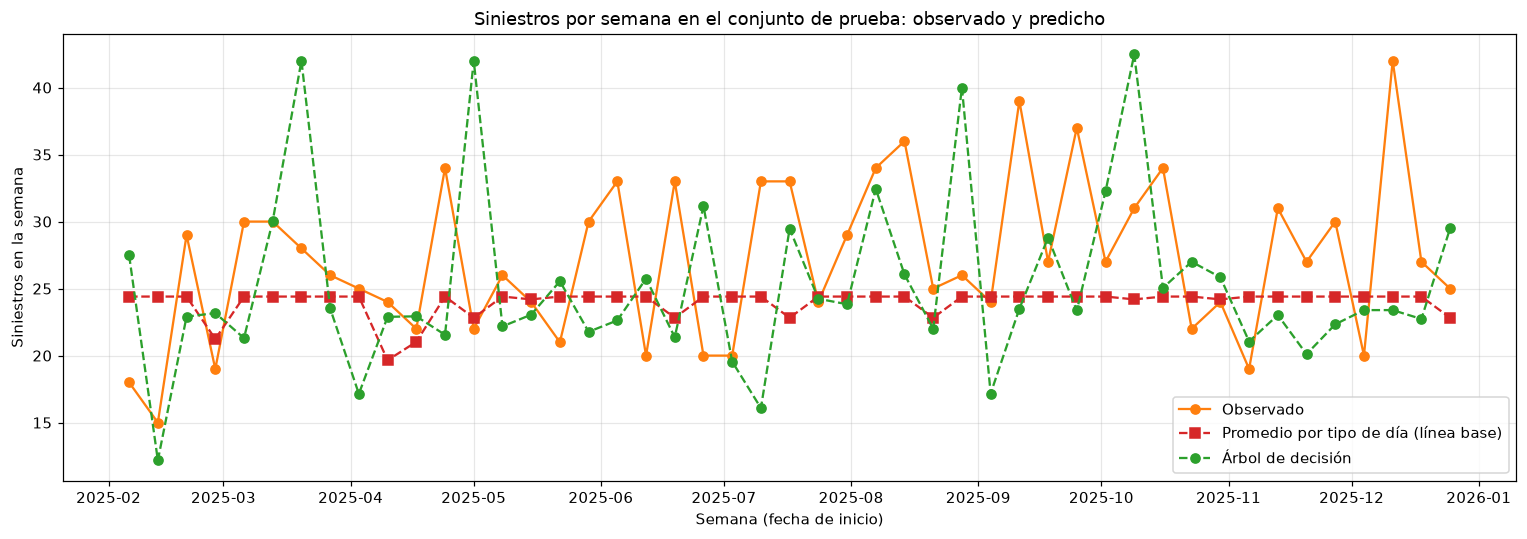

In [25]:
fechas_semanas = pd.to_datetime(semanal["desde"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fechas_semanas, semanal["observado_total"], marker="o", color="tab:orange", label="Observado")
ax.plot(fechas_semanas, semanal[f"total | {LINEA_BASE}"], marker="s", linestyle="--", color="tab:red",
        label=LINEA_BASE)
ax.plot(fechas_semanas, semanal[f"total | {ARBOL}"], marker="o", linestyle="--", color="tab:green",
        label=ARBOL)

ax.set_title("Siniestros por semana en el conjunto de prueba: observado y predicho")
ax.set_xlabel("Semana (fecha de inicio)")
ax.set_ylabel("Siniestros en la semana")
ax.legend()
plt.tight_layout()
guardar_figura(fig, "fig9_test_totales_semanales.png")
plt.show()

figura guardada: experiments/base_2/figuras/fig10_test_mae_semanal.png


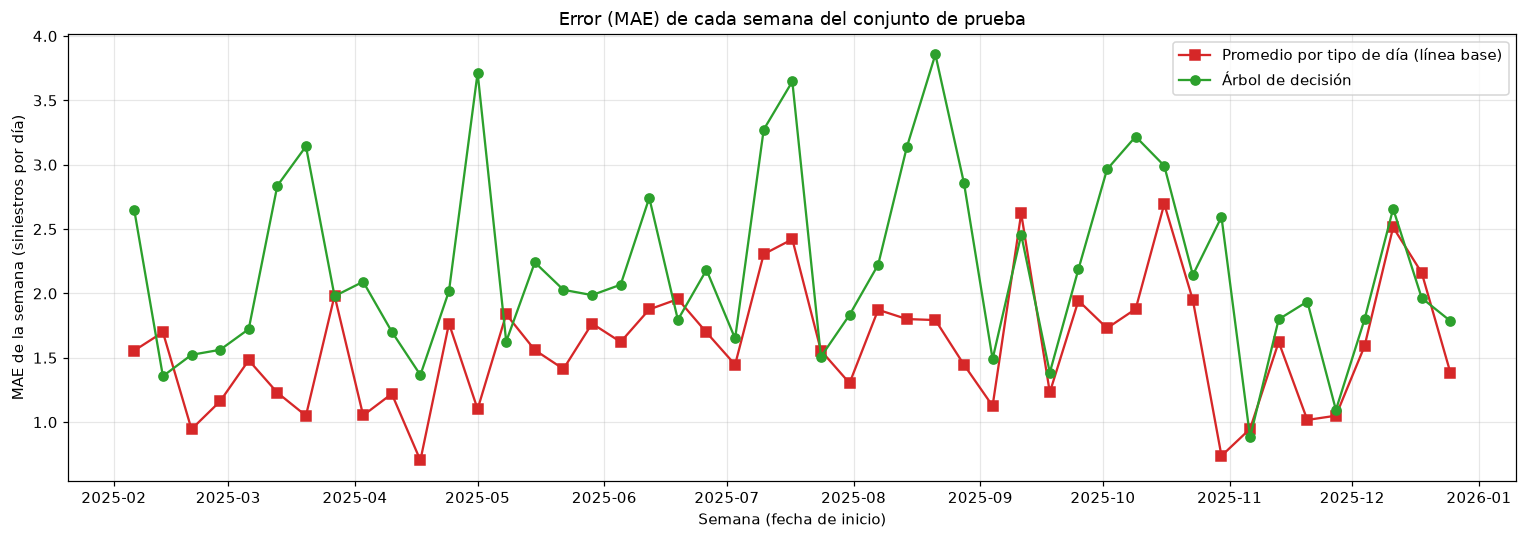

In [26]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fechas_semanas, semanal[f"MAE | {LINEA_BASE}"], marker="s", color="tab:red", label=LINEA_BASE)
ax.plot(fechas_semanas, semanal[f"MAE | {ARBOL}"], marker="o", color="tab:green", label=ARBOL)

ax.set_title("Error (MAE) de cada semana del conjunto de prueba")
ax.set_xlabel("Semana (fecha de inicio)")
ax.set_ylabel("MAE de la semana (siniestros por día)")
ax.legend()
plt.tight_layout()
guardar_figura(fig, "fig10_test_mae_semanal.png")
plt.show()

**Lectura** (tablas `08_test_metricas`, `09_test_semanal` y `10_test_variabilidad_semanal`; figuras
`fig9_test_totales_semanales` y `fig10_test_mae_semanal`).

| Modelo | MAE en las 47 semanas | Diferencia con la línea base |
| --- | --- | --- |
| **Promedio por tipo de día (línea base)** | **1,592** | — |
| Media constante | 1,741 | +9,4 % |
| Árbol de decisión | 2,206 | +38,6 % |
| Repetir semana anterior | 2,228 | +40,0 % |

- **La línea base es la mejor, y el árbol es peor incluso que predecir siempre el promedio.** Solo le
  gana a la línea base en **8 de las 47 semanas**.
- **Control:** la línea base y la media constante dan el mismo MAE que en `base.ipynb` (diferencias de
  0,0001), así que las cifras de los dos notebooks son comparables.
- **Una semana no alcanzaba.** El MAE semanal del árbol va de **0,88 a 3,86** según la semana, y el de
  la línea base de 0,70 a 2,70. Con una semana cualquiera, cualquier modelo podía parecer bueno o malo.
- **El árbol se «engancha» en valores altos.** Como usa sus propias predicciones para seguir
  prediciendo, en 4 semanas predijo 40 o más siniestros (las que empiezan el 20/3, 1/5, 28/8 y 9/10),
  cuando hubo entre 22 y 31 (figura 9).
- **La línea base y la media constante predicen el 88,4 % de lo ocurrido.** Aprendieron el nivel de
  entrenamiento (3,426 por día) y la prueba promedia 3,875. Las semanas con más siniestros (42 la del
  11/12 y 39 la del 11/9) quedan muy por encima de lo que predice la línea base, unos 24 por semana. El
  árbol parece mejor en este indicador (93,1 %), pero solo porque sus excesos y sus faltas se
  compensan: su error día a día es mucho mayor.

## 10. Conclusiones

**Lo que muestran los datos** (evidencia):

1. En todo el conjunto de prueba, la **línea base** (promedio por tipo de día) tiene el menor error:
   MAE **1,592**. El árbol de decisión llega a **2,206**, un 38,6 % peor, y queda detrás de la media
   constante (1,741).
2. El árbol **memoriza**: 527 hojas para 1.309 filas de entrenamiento.
3. Los días anteriores se parecen poco al día a predecir (autocorrelación máxima 0,165). Lo que se
   repite es el **patrón semanal**: 1,96 siniestros de promedio los domingos contra 4,19 los viernes.
4. Evaluar una sola semana es engañoso: el MAE semanal del árbol va de 0,88 a 3,86.
5. La prueba promedia un 13 % más de siniestros por día que el entrenamiento, y los modelos que
   aprenden un nivel fijo predicen de menos (88,4 % del total).

**Lo que concluye el equipo** (inferencia):

- Los resultados sugieren que, con solo los 7 días anteriores, el árbol no encuentra información que
  mejore lo que ya da el calendario. Coincide con el diagnóstico de datos: la señal útil está en el tipo
  de día, no en los días previos.
- La línea base del proyecto se mantiene: **promedio por tipo de día**. Cualquier modelo del Entregable
  3 tiene que superarla con este mismo procedimiento de evaluación.
- Un modelo mejor necesitaría, como mínimo, el **calendario como variable**, una profundidad elegida con
  datos de validación (no a mano) y alguna forma de seguir el **crecimiento** de los siniestros.

**Límites:** un solo municipio y un solo horizonte (7 días). Nada de esto permite afirmar cómo funciona
el modelo en el resto de Montevideo.